The standard approach to two-qubit gate synthesis is to fix a parameterized ansatz - alternating entangling gates and single-qubit rotations - then run a numerical optimizer to match a target unitary. Let's try it.

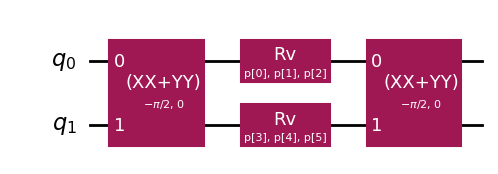

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import RVGate, iSwapGate
from qiskit.quantum_info import Operator
from qiskit.quantum_info.random import random_unitary
from scipy.optimize import minimize
from tqdm import tqdm

from gulps.core.invariants import GateInvariants
from gulps.viz.invariant_viz import scatter_plot

N = 32
sentence_length = 2
random_restarts = 1
basis_gate = iSwapGate()


def ansatz():
    num_params = 6 * sentence_length
    p = ParameterVector("p", num_params)
    qc = QuantumCircuit(2)
    for i in range(sentence_length - 1):
        qc.append(basis_gate.power(0.5), [0, 1])
        qc.append(RVGate(p[0 + 6 * i], p[1 + 6 * i], p[2 + 6 * i]), [0])
        qc.append(RVGate(p[3 + 6 * i], p[4 + 6 * i], p[5 + 6 * i]), [1])
    qc.append(basis_gate.power(0.5), [0, 1])
    return qc, num_params


ansatz_qc, num_params = ansatz()
ansatz_qc.draw("mpl")

This tries to decompose random unitaries by minimizing the Makhlin invariant distance. There are two problems. First, we fixed the sentence length to 2, but we don't know the right length ahead of time (and for a mixed ISA, we don't even know which combination of gates to use). We'd need an outer loop over candidate ansatze, keeping the cheapest one that converges. Second, plenty of targets may fail to converge even with multiple restarts, which makes that outer search even more expensive because it is unclear when we are confident enough to try the next most expensive ansatze.

Naive synthesis:   0%|          | 0/32 [00:00<?, ?it/s]

Naive synthesis: 100%|██████████| 32/32 [00:13<00:00,  2.37it/s]

Converged: 24/32


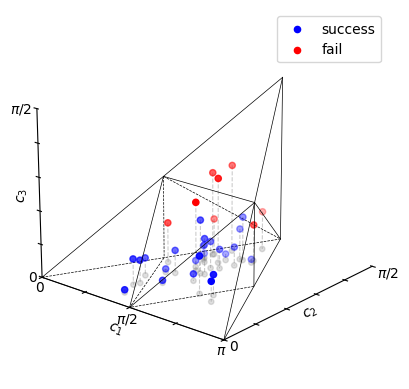

In [2]:
def bind_ansatz(p):
    bound_qc = ansatz_qc.assign_parameters(
        {param: val for param, val in zip(ansatz_qc.parameters, p)}
    )
    return GateInvariants.from_unitary(Operator(bound_qc))


successes = []
failures = []
for target_gate in tqdm(
    (GateInvariants.from_unitary(random_unitary(4)) for _ in range(N)),
    total=N,
    desc="Naive synthesis",
):

    def makhlin_objective(p):
        U = bind_ansatz(p)
        return np.linalg.norm(np.array(U.makhlin) - np.array(target_gate.makhlin)) ** 2

    succeeded = False
    for _ in range(random_restarts):
        attempt = minimize(
            makhlin_objective,
            x0=np.pi * np.random.rand(num_params) - np.pi / 2,
            method="Nelder-Mead",
        )
        if attempt.success and attempt.fun < 1e-4:
            successes.append(target_gate)
            succeeded = True
            break
    if not succeeded:
        failures.append(target_gate)

print(f"Converged: {len(successes)}/{N}")
fig, ax = scatter_plot(successes, color="blue", label="success")
scatter_plot(failures, ax=ax, color="red", label="fail")
ax.legend()

The gaps in the Weyl chamber are structural as the optimizer has no guidance about which region of parameter space to search. We can also see what the ansatz *can* reach by randomly sampling its parameters.

100%|██████████| 1024/1024 [00:00<00:00, 2160.70it/s]


(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

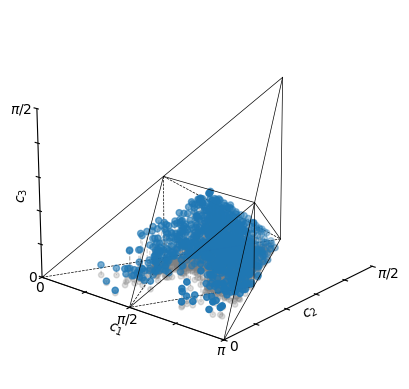

In [3]:
random_inv_list = []
for _ in tqdm(range(1024)):
    p = np.pi * np.random.rand(num_params) - np.pi / 2
    random_inv_list.append(bind_ansatz(p))
scatter_plot(random_inv_list)

GULPS solves this by using monodromy polytopes to describe exactly which two-qubit unitaries are reachable by each gate sequence ("sentence"). The union of these polytopes tiles the Weyl chamber. Sentence selection becomes a geometric containment problem rather than a numerical search.

To see the coverage, pass `precompute_polytopes=True` when building the ISA. This requires the optional `monodromy` extra (`pip install gulps[monodromy]`).

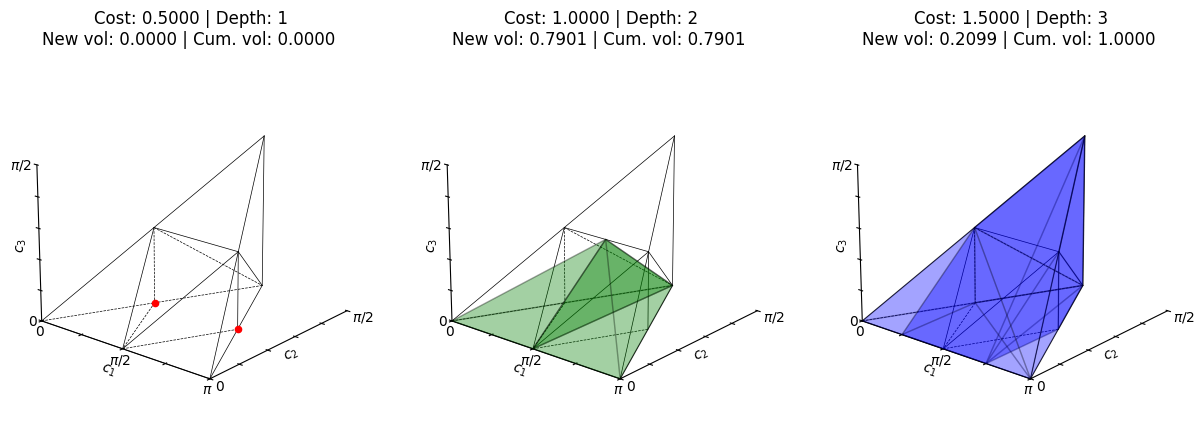

Coverage Set Statistics (Haar-averaged over SU(4))
Expected Cost:  1.104941
  Average cost per random 2-qubit unitary

Expected Depth: 2.209883
  Average number of 2-qubit gates


In [4]:
from qiskit.circuit.library import iSwapGate
from gulps.core.isa import DiscreteISA
from gulps.core.coverage import coverage_report

isa = DiscreteISA(
    gate_set=[basis_gate.power(1 / 2)],
    costs=[1 / 2],
    precompute_polytopes=True,
)
coverage_report(isa.coverage_set);

Given a target unitary, GULPS picks the cheapest sentence whose polytope contains the target, using a linear program to find a trajectory through the Weyl chamber from identity to target, with one intermediate waypoint per gate in the sentence.

`_best_decomposition` returns the chosen sentence, intermediates, and cost. This is useful on its own for evaluating circuit costs without running a full numerical synthesis.

Sentence: ['2QGate', '2QGate', '2QGate']
Cost: 1.5000
Intermediates: 3 points


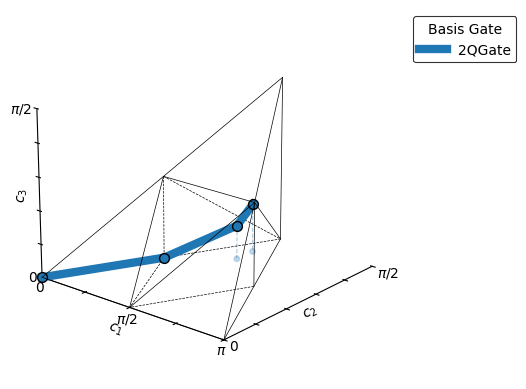

In [5]:
from gulps import GulpsDecomposer, GateInvariants
from gulps.viz.invariant_viz import plot_decomposition

decomposer = GulpsDecomposer(isa=isa)

target = GateInvariants.from_unitary(random_unitary(4, seed=31))
result = decomposer._best_decomposition(target)

print(f"Sentence: {[g.name for g in result.sentence]}")
print(f"Cost: {result.cost:.4f}")
print(f"Intermediates: {len(result.intermediates)} points")

plot_decomposition(result.intermediates, result.sentence, isa);

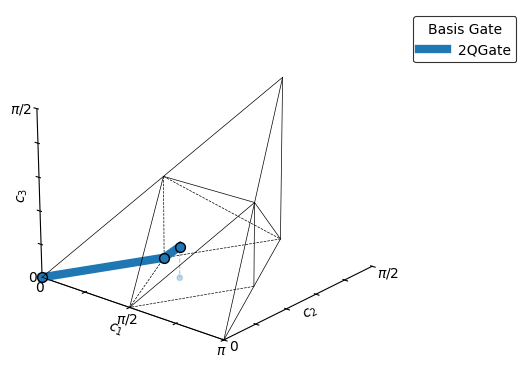

In [6]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import time

for _i in range(20):
    clear_output(wait=True)
    r = decomposer._best_decomposition(GateInvariants.from_unitary(random_unitary(4)))
    fig = plot_decomposition(r.intermediates, r.sentence, isa)
    display(fig)
    plt.close(fig)
    time.sleep(0.15)

Each consecutive pair of intermediates defines a "segment" - a depth-2 subcircuit with one entangling gate and unknown single-qubit corrections. GULPS solves for these corrections using a Gauss-Newton solver on the Makhlin invariants, followed by a Weyl-coordinate polish.

In [11]:
solutions = decomposer._local_synthesis._solve_segments(
    result.sentence, result.intermediates, n_inner=len(result.sentence) - 1
)
solutions

[SegmentSolution(u0=array([[ 0.64270487-0.40052839j,  0.14040551+0.63780385j],
        [-0.14040551+0.63780385j,  0.64270487+0.40052839j]]), u1=array([[ 0.81013689-0.50487064j,  0.0640616 +0.29099824j],
        [-0.0640616 +0.29099824j,  0.81013689+0.50487064j]]), max_residual=6.968869925572108e-13, success=True, metadata={}),
 SegmentSolution(u0=array([[-0.04909357-0.5400336j , -0.59727027-0.59094988j],
        [ 0.59727027-0.59094988j, -0.04909357+0.5400336j ]]), u1=array([[ 0.70999193+0.42028619j,  0.50762426+0.24817049j],
        [-0.50762426+0.24817049j,  0.70999193-0.42028619j]]), max_residual=0.0, success=True, metadata={})]

After solving all segments, a stitching step recovers global unitary equivalence from the local (invariant-level) solutions.

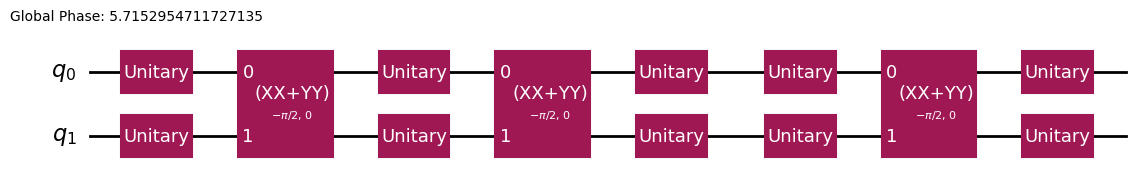

In [12]:
circuit = decomposer._local_synthesis.synthesize_segments(
    gate_list=result.sentence,
    invariant_list=result.intermediates,
    target=target,
)
circuit.draw("mpl")

---

`single_qubit_cost` adds a small cost ε per gate to guarantee that shorter sentences are always cheaper when entangling costs are equal. For example, 2 iSwaps and 4 √iSwaps both have entangling cost 2, but the total costs become 2+3ε vs 2+5ε. In practice the priority-queue enumeration already explores shorter sentences first, so the default ε ≈ 1e-8 is a safety net rather than a knob you need to tune. This can be a useful parameter when single qubit gates aren't considered trivially free, or if the cost of small fractional basis gates is comparable to single qubit gates.

In [13]:
# With a large single_qubit_cost, shorter sentences are preferred even if
# they have higher entangling cost.  Here 3×sq4iswap has lower entangling
# cost (0.75) than 2×sq2iswap (1.0), but the per-gate penalty flips the winner.
gate_set = [basis_gate.power(1 / 2), basis_gate.power(1 / 4)]
costs = [1 / 2, 1 / 4]
names = ["sq2iswap", "sq4iswap"]

dec_default = GulpsDecomposer(
    isa=DiscreteISA(gate_set=gate_set, costs=costs, names=names)
)
dec_heavy = GulpsDecomposer(
    isa=DiscreteISA(gate_set=gate_set, costs=costs, names=names, single_qubit_cost=0.5)
)

target = GateInvariants.from_unitary(random_unitary(4, seed=138))
r1 = dec_default._best_decomposition(target)
r2 = dec_heavy._best_decomposition(target)
print(f"Default (ε):       {[g.name for g in r1.sentence]}  cost={r1.cost:.4f}")
print(f"Heavy sq (0.5):    {[g.name for g in r2.sentence]}  cost={r2.cost:.4f}")

Default (ε):       ['sq4iswap', 'sq4iswap', 'sq4iswap']  cost=0.7500
Heavy sq (0.5):    ['sq2iswap', 'sq2iswap']  cost=2.5000


`GulpsConfig` has a few other options. The defaults are tuned to work generically across ISA families, but there is no one-size-fits-all for arbitrary gate sets. You shouldn't need to touch these unless debugging a specific failure.

- `flag_duration` - warn when a decomposition exceeds this time in seconds (default 0.05). Set to 0 to disable.
- `makhlin_conv_tol`, `weyl_conv_tol` - convergence tolerances for the two solver stages.

The ISA itself carries a `max_sequence_length` parameter (default 8) that controls how deep the sentence enumeration goes. For very weak gates (e.g. CX^(1/4)), increase this at ISA construction time.

---

Where does the time go? The loop below decomposes 1000 Haar-random unitaries. For most ISAs, the LP is negligible and nearly all time is in the numerical solver.

In [ ]:
from qiskit.quantum_info import Operator, average_gate_fidelity
from gulps.viz.report_viz import report_benchmark_results
from tqdm import trange

fidelities = []
all_timings = []
failures = 0

for idx in trange(1024, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        fid = average_gate_fidelity(u, Operator(decomposer(u)))
        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")
        fidelities.append(fid)
        all_timings.append(decomposer.last_timing)
    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

Decomposing random unitaries: 100%|██████████| 1024/1024 [00:01<00:00, 873.62it/s]


Benchmark: 1024/32 successful (0 failures)
Fidelity: median=1.0000000000, min=1.0000000000
Avg time: 344.6 us/decomposition


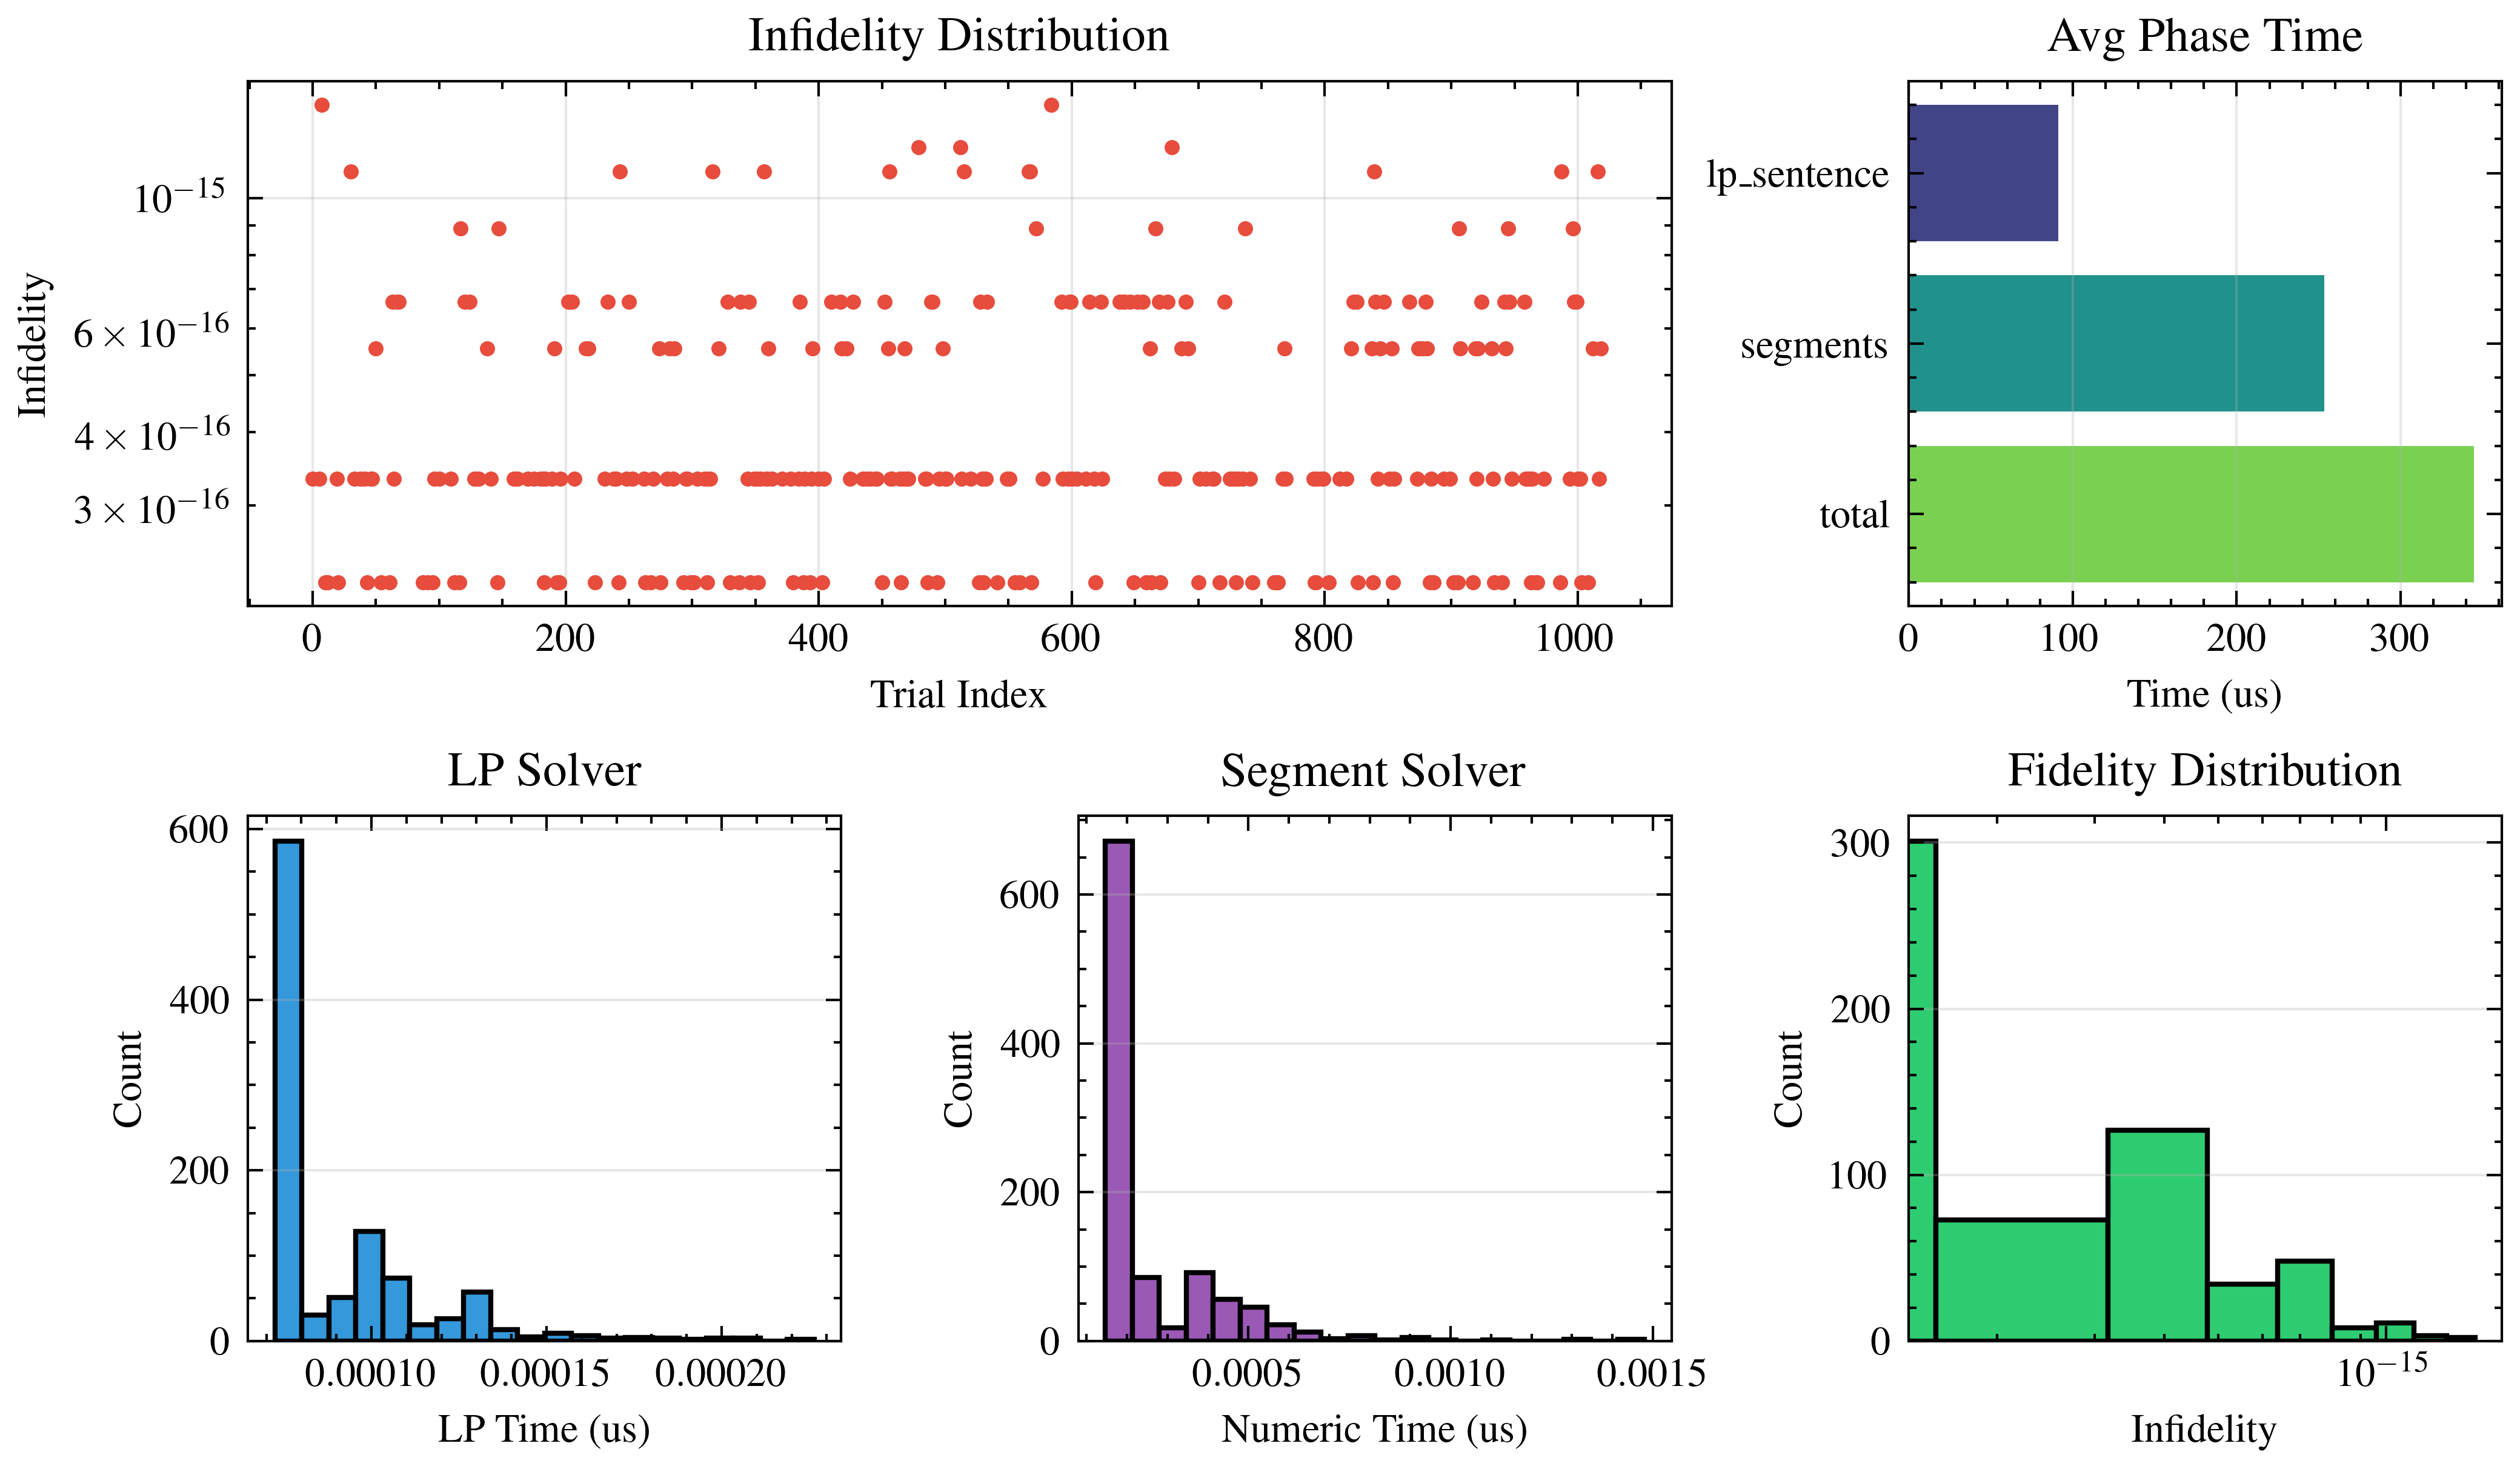

In [15]:
report_benchmark_results(fidelities, all_timings, decomposer, N, failures)